        Project Title:
Netflix Dataset Exploratory Data Analysis

        Objective:
Analyze the Netflix dataset to discover trends, patterns, and insights related to movies and TV shows.

        Research Questions
1- What is the ratio of Movies to TV Shows on Netflix?
2- Which countries produce the highest amount of Netflix content?
3- What are the most common content ratings on Netflix?
4- How has Netflix content production changed over the years?
5- Which genres are the most popular on Netflix?
6- How many missing values exist in the dataset, and in which columns?

In [154]:
import pandas as pd 

In [155]:
df = pd.read_csv ("netflix_titles.csv")   

In [156]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [157]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

In [158]:
df.drop_duplicates(inplace=True)
print("Shape:", df.shape)

Shape: (8807, 12)


In [159]:
print(df['type'].value_counts())

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [160]:
print(df["country"].value_counts().head(10))

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


In [161]:
print(df['rating'].value_counts())

rating
TV-MA        3207
TV-14        2160
TV-PG         863
R             799
PG-13         490
TV-Y7         334
TV-Y          307
PG            287
TV-G          220
NR             80
G              41
TV-Y7-FV        6
Not Rated       4
NC-17           3
UR              3
74 min          1
84 min          1
66 min          1
Name: count, dtype: int64


In [162]:
print(df['release_year'].describe())

count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64


                                         Key Insights
1- Movies significantly outnumber TV Shows on Netflix.
2- The United States is one of the leading countries producing content on Netflix.
3- The amount of content released on Netflix has increased considerably since 2015.
4-TV-MA is among the most common content ratings on the platform.
5-Missing values were identified in several columns, such as director and country, and were handled during the data cleaning     process.

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns

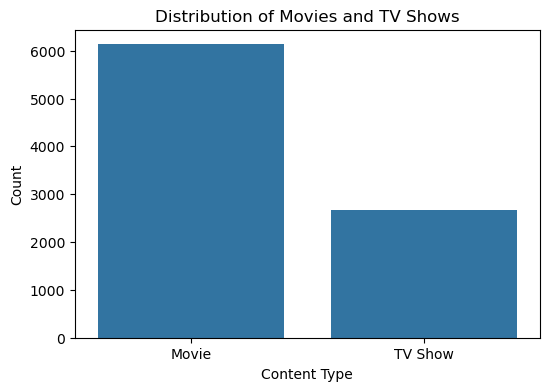

In [165]:
plt.figure(figsize=(6,4))
sns.countplot(data=df ,x="type" )
plt.title('Distribution of Movies and TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

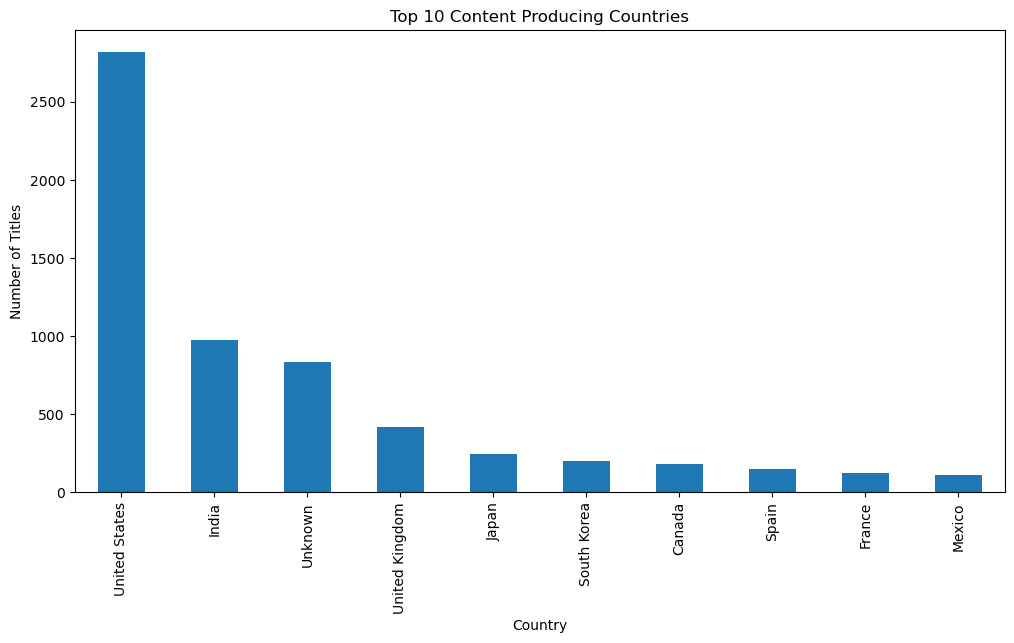

In [166]:
plt.figure(figsize=(12,6))
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Content Producing Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.show()

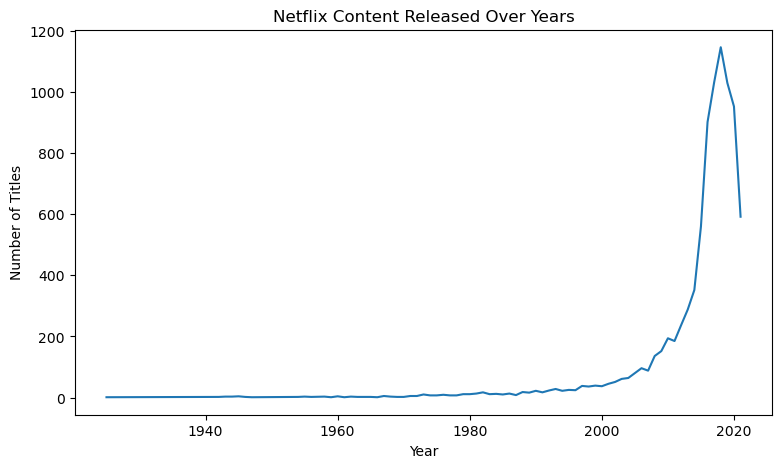

In [167]:
plt.figure(figsize=(9,5))
df['release_year'].value_counts().sort_index().plot()
plt.title('Netflix Content Released Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

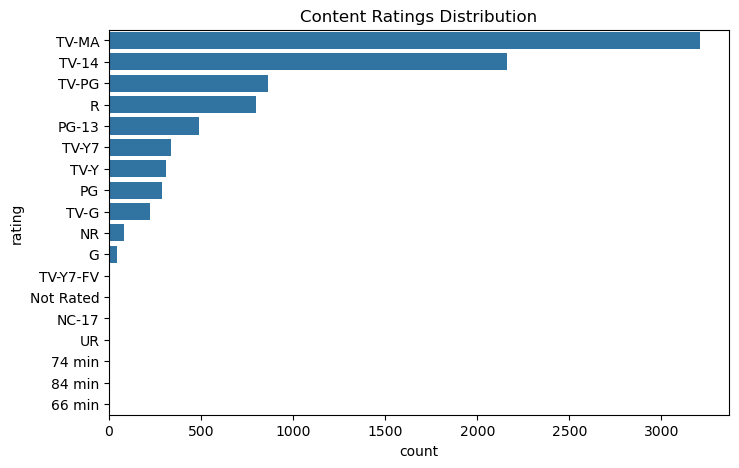

In [168]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,y='rating',order=df['rating'].value_counts().index)
plt.title('Content Ratings Distribution')
plt.show()

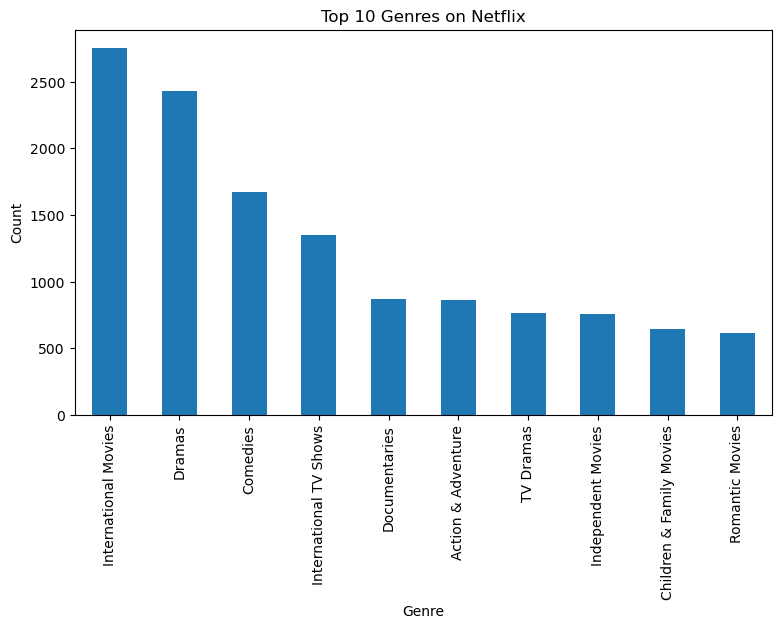

In [169]:
genres = df['listed_in'].str.split(', ').explode()
plt.figure(figsize=(9,5))
genres.value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()

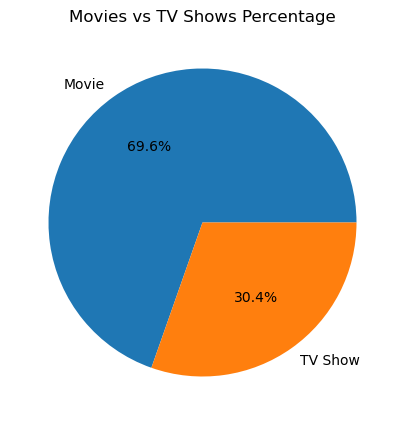

In [170]:
type_counts = df['type'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(type_counts,labels=type_counts.index,autopct='%1.1f%%')
plt.title('Movies vs TV Shows Percentage')
plt.show()

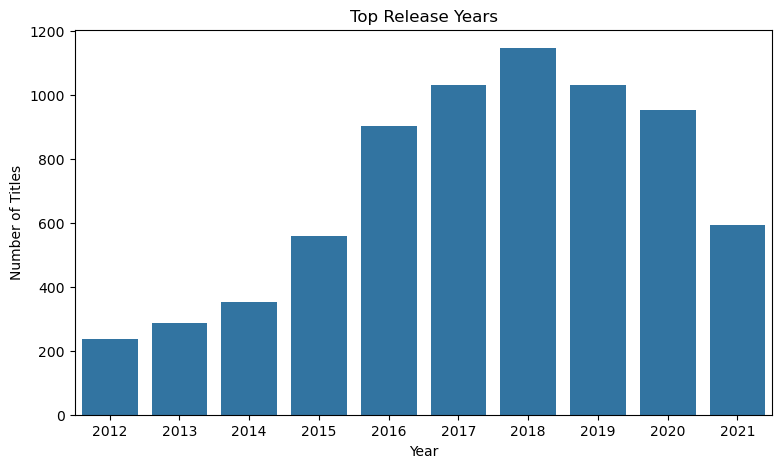

In [171]:
top_years = df['release_year'].value_counts().head(10)
plt.figure(figsize=(9,5))
sns.barplot(x=top_years.index,y=top_years.values)
plt.title('Top Release Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

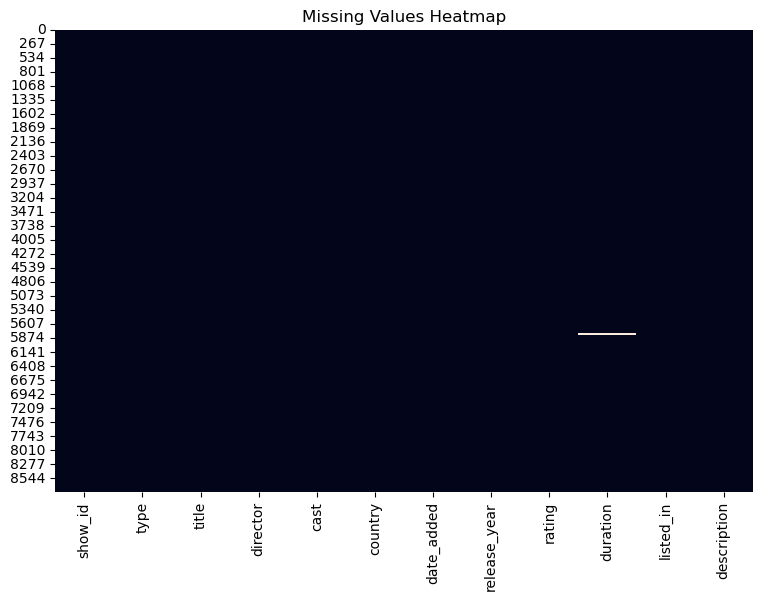

In [172]:
import seaborn as sns
plt.figure(figsize=(9,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()

                               Task 4: Sentiment Analysis

In [174]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

In [175]:
df = pd.read_csv('netflix_titles.csv')
df = df[['title', 'description']]
df.dropna(inplace=True)

In [176]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

In [177]:
df['Sentiment'] = df['description'].apply(get_sentiment)
print(df['Sentiment'].value_counts())

Sentiment
Positive    4547
Negative    2662
Neutral     1598
Name: count, dtype: int64


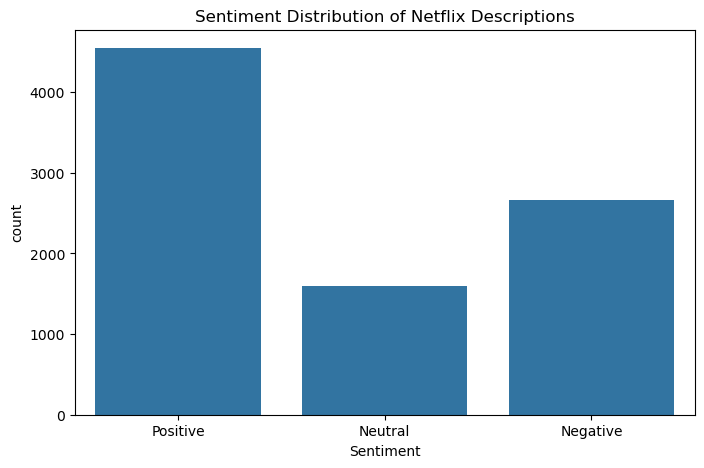

In [178]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='Sentiment')
plt.title('Sentiment Distribution of Netflix Descriptions')
plt.show()

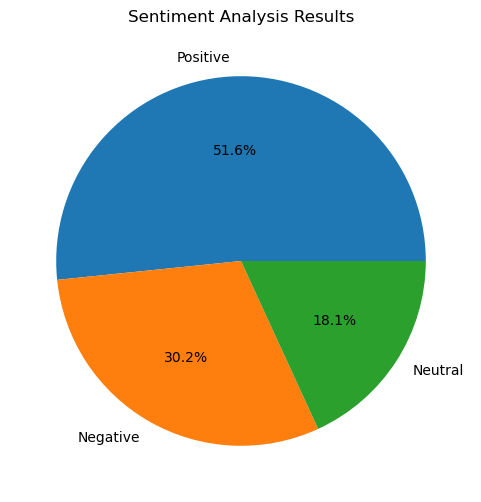

In [179]:
sentiment_counts = df['Sentiment'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts,labels=sentiment_counts.index,autopct='%1.1f%%')
plt.title('Sentiment Analysis Results')
plt.show()

In [180]:
print(df[['title','Sentiment']].head(10))

                              title Sentiment
0              Dick Johnson Is Dead  Positive
1                     Blood & Water   Neutral
2                         Ganglands  Negative
3             Jailbirds New Orleans  Negative
4                      Kota Factory   Neutral
5                     Midnight Mass   Neutral
6  My Little Pony: A New Generation   Neutral
7                           Sankofa  Negative
8     The Great British Baking Show  Positive
9                      The Starling   Neutral
